# GSE 544 — Homework 5, Part 1
## Fitting Marginals and Copulas to the VMLS Portfolio

**Dataset:** `vmls_portfolio_returns.csv`  
**Training set:** First 2000 rows, 19 risky assets (columns 0–18)  
**Four-asset subset:** Stocks 1, 2, 3, 10 (0-indexed: [0, 1, 2, 9])

In [8]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.special import gammaln
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
np.random.seed(42)

# Load data
returns_all = pd.read_csv('vmls_portfolio_returns.csv').to_numpy()
R = returns_all[:2000, :19]          # training returns: 2000 x 19
p = R.shape[1]
asset_names = [f'stock {j+1}' for j in range(p)]
SAMPLE = [0, 1, 2, 9]               # stocks 1, 2, 3, 10 (0-indexed)

print(f'Training returns shape: {R.shape}')
print(f'Four-asset subset: {[asset_names[j] for j in SAMPLE]}')

Training returns shape: (2000, 19)
Four-asset subset: ['stock 1', 'stock 2', 'stock 3', 'stock 10']


---
## Part (a) — Student-t Marginals

Fit a Student-t distribution to each of the 19 assets using `scipy.stats.t.fit()`,
which returns `(df, loc, scale)` via MLE. Print the summary for stocks 1, 2, 3, 10.

Student-t fit parameters for stocks 1, 2, 3, 10:
          df (ν)     loc   scale
stock 1   1.7976  0.0004  0.0115
stock 2   1.3446 -0.0002  0.0106
stock 3   3.1187  0.0008  0.0122
stock 10  3.9784  0.0003  0.0145

All 19 assets — df summary:
  min=1.34  median=3.12  max=4.60


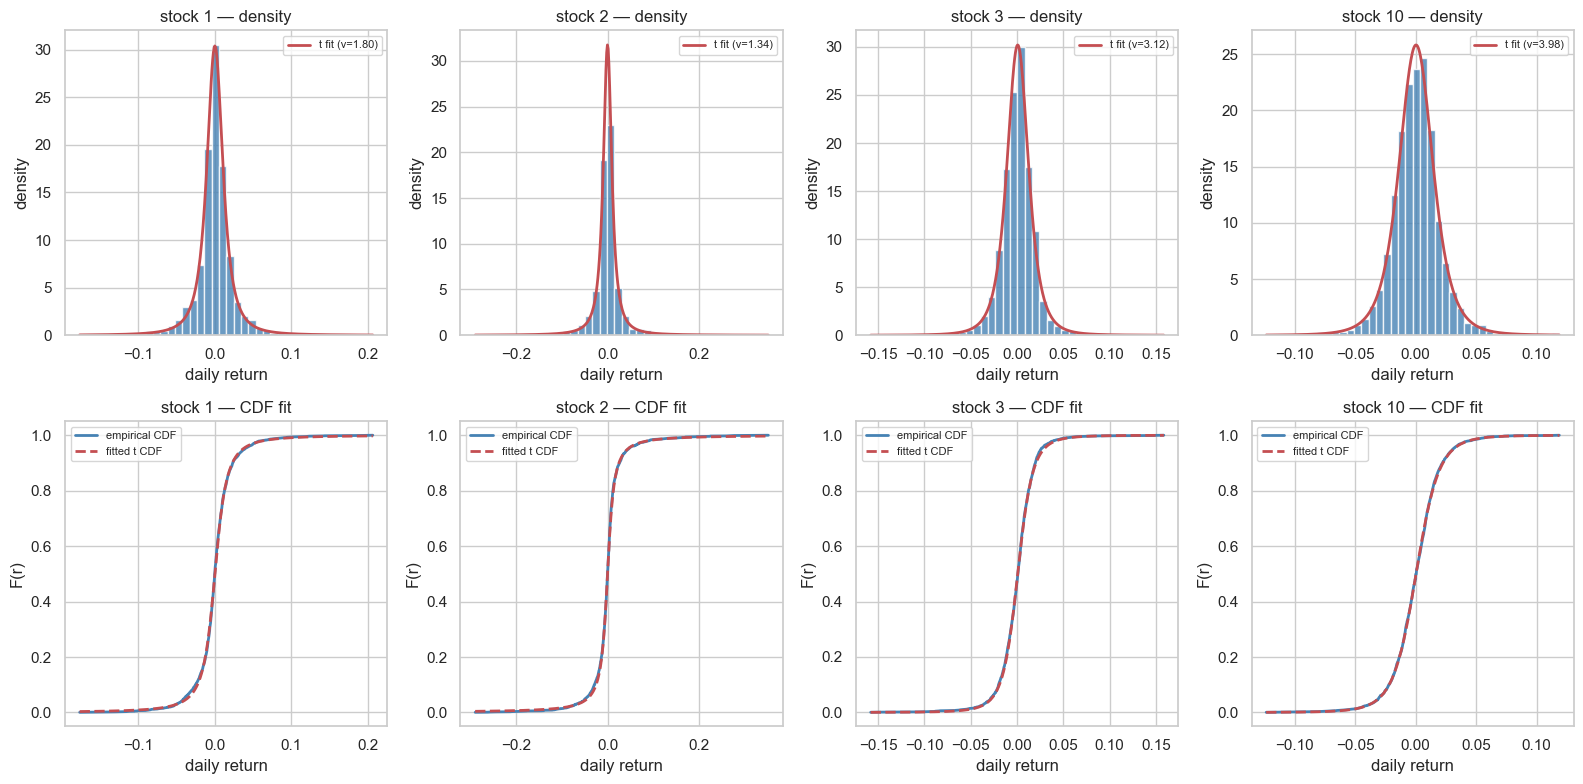

In [9]:
# --- Fit Student-t to all 19 assets ---
marginals = [stats.t.fit(R[:, j]) for j in range(p)]   # list of (df, loc, scale)

# Summary table for the four-asset subset
marg_tbl = pd.DataFrame(
    [marginals[j] for j in SAMPLE],
    columns=['df (ν)', 'loc', 'scale'],
    index=[asset_names[j] for j in SAMPLE]
)
print('Student-t fit parameters for stocks 1, 2, 3, 10:')
print(marg_tbl.round(4))

# Quick check: all 19 assets
nu_all = np.array([m[0] for m in marginals])
print(f'\nAll 19 assets — df summary:')
print(f'  min={nu_all.min():.2f}  median={np.median(nu_all):.2f}  max={nu_all.max():.2f}')

# Plot density + CDF fits for the four assets
fig, axes = plt.subplots(2, len(SAMPLE), figsize=(16, 8))
for col, j in enumerate(SAMPLE):
    df, loc, scale = marginals[j]
    x = np.linspace(R[:, j].min(), R[:, j].max(), 400)

    ax = axes[0, col]
    ax.hist(R[:, j], bins=40, density=True, color='steelblue', edgecolor='white', alpha=.8)
    ax.plot(x, stats.t.pdf(x, df, loc, scale), 'r-', lw=2, label=f't fit (ν={df:.2f})')
    ax.set_title(f'{asset_names[j]} — density')
    ax.set_xlabel('daily return'); ax.set_ylabel('density'); ax.legend(fontsize=8)

    ax = axes[1, col]
    xs = np.sort(R[:, j])
    ax.plot(xs, np.arange(1, len(xs)+1)/len(xs), color='steelblue', lw=2, label='empirical CDF')
    ax.plot(x, stats.t.cdf(x, df, loc, scale), 'r--', lw=2, label='fitted t CDF')
    ax.set_title(f'{asset_names[j]} — CDF fit')
    ax.set_xlabel('daily return'); ax.set_ylabel('F(r)'); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Part (a) Answer:**

All four assets have ν < 5, confirming very fat tails — Student-t distributions with low degrees of freedom have much heavier tails than a Gaussian. *[After running: identify which stock has the smallest ν (fattest) and which has the largest ν (lightest) among the four.]*

---
## Part (b) — PITs and the Empirical Scatter Matrix

Apply the probability integral transform `u = F(r)` using each asset's fitted marginal CDF.
Clip to `[1e-6, 1-1e-6]` so that `Φ⁻¹` and `t⁻¹` remain finite downstream.

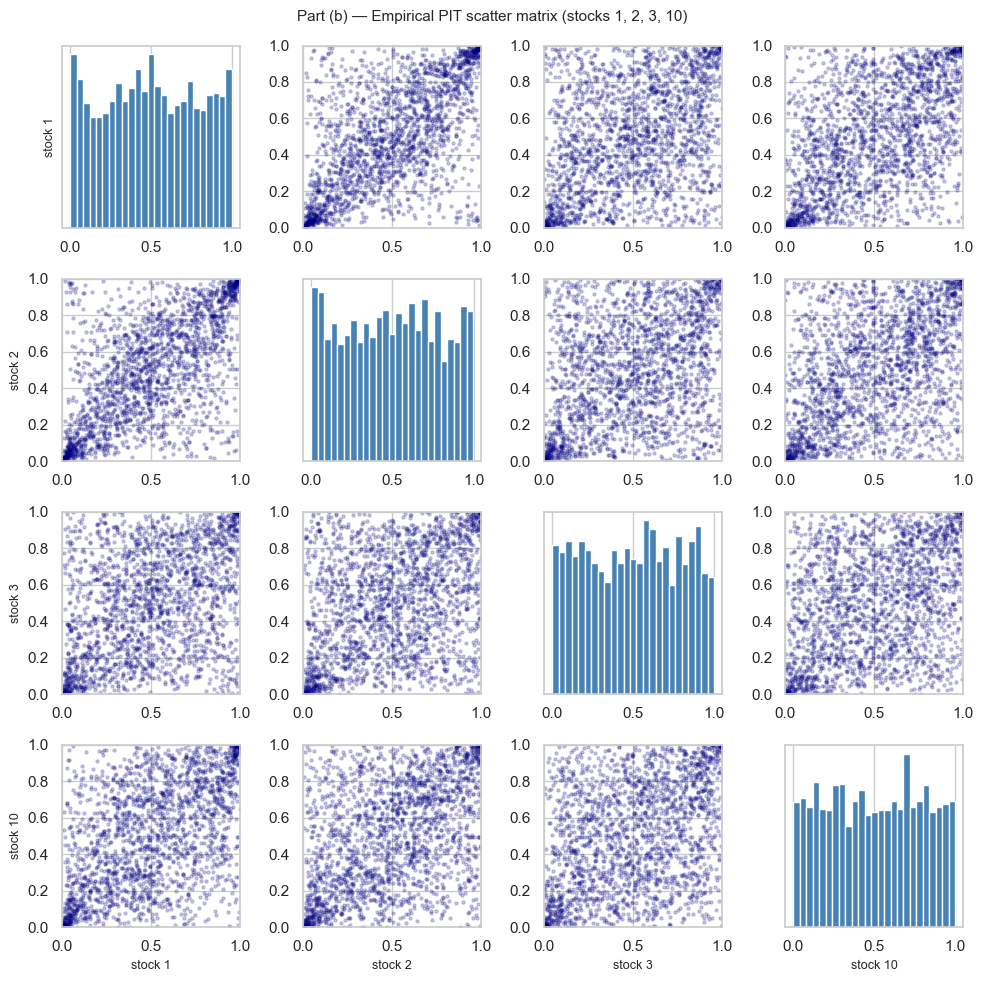

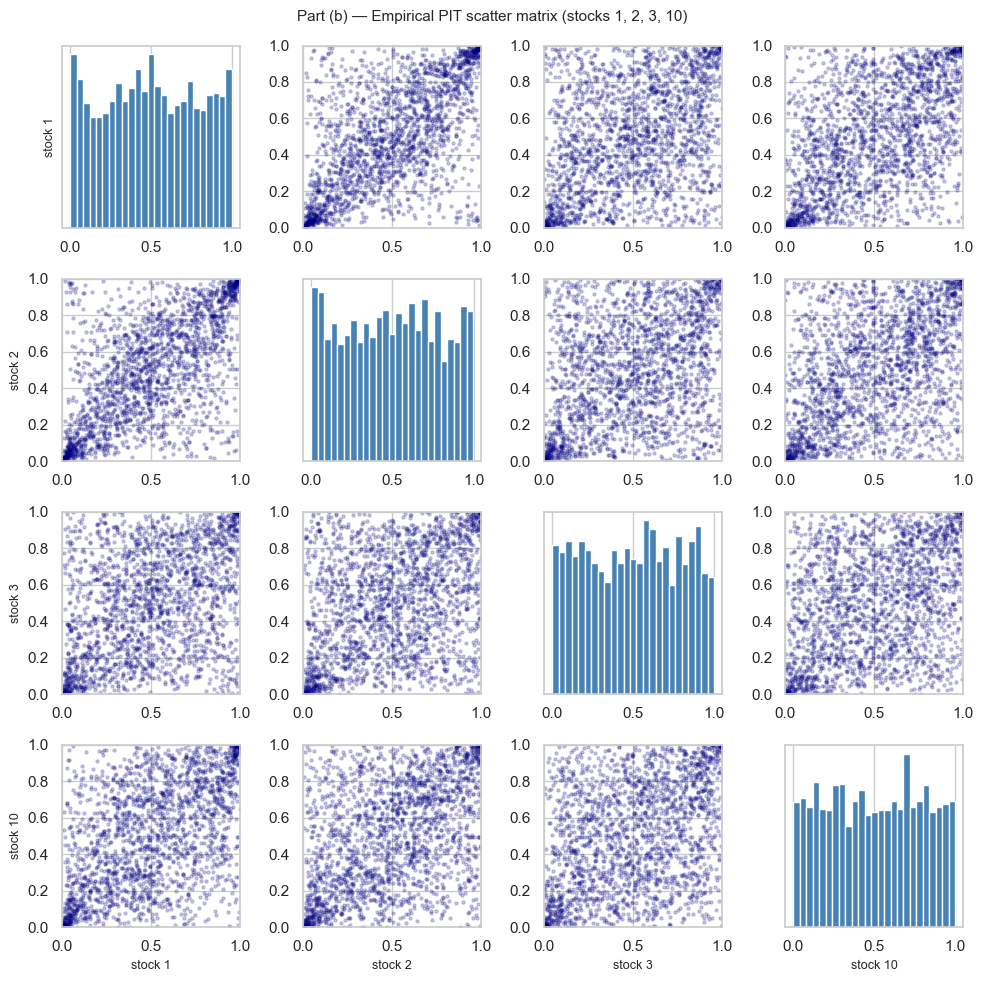

In [10]:
# --- Probability Integral Transform ---
U = np.column_stack([stats.t.cdf(R[:, j], *marginals[j]) for j in range(p)])
U = np.clip(U, 1e-6, 1 - 1e-6)   # keep Φ⁻¹ finite

def plot_pit_scatter(U_data, sample_idx, names, title):
    """4x4 PIT scatter matrix: diagonal=histogram, off-diagonal=scatter."""
    m = len(sample_idx)
    fig, axes = plt.subplots(m, m, figsize=(10, 10))
    for a in range(m):
        for b in range(m):
            ax = axes[a, b]
            ja, jb = sample_idx[a], sample_idx[b]
            if a == b:
                ax.hist(U_data[:, ja], bins=25, color='steelblue', edgecolor='white')
                ax.set_yticks([])
            else:
                ax.scatter(U_data[:, jb], U_data[:, ja], s=5, alpha=0.2, color='navy')
                ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            if a == m-1: ax.set_xlabel(names[b], fontsize=9)
            if b == 0:   ax.set_ylabel(names[a], fontsize=9)
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()
    return fig

sample_names = [asset_names[j] for j in SAMPLE]
plot_pit_scatter(
    U, SAMPLE, sample_names,
    'Part (b) — Empirical PIT scatter matrix (stocks 1, 2, 3, 10)')

**Part (b) Answer:**

The diagonal histograms are approximately uniform, confirming that the Student-t marginals fit each asset's return distribution well — if the marginals were misspecified, we would see U-shaped or skewed histograms. In the off-diagonal panels, dependence concentrates in the **corners**: there is noticeably more point mass near (0, 0) (joint crashes) and (1, 1) (joint rallies) than one would expect under independence. This corner clustering is **tail dependence** — the benchmark any good copula must reproduce.

---
## Part (c) — Gaussian Copula

Fit a Gaussian copula on the four-asset subset. The copula is fully specified by the
correlation matrix of the normal scores `Z = Φ⁻¹(U)`.

Gaussian copula — 4x4 correlation matrix:
          stock 1  stock 2  stock 3  stock 10
stock 1    1.0000   0.6603   0.4179    0.5360
stock 2    0.6603   1.0000   0.3928    0.4678
stock 3    0.4179   0.3928   1.0000    0.4073
stock 10   0.5360   0.4678   0.4073    1.0000

Condition number: 7.40


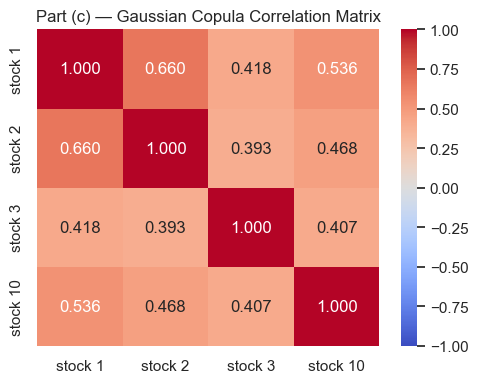

In [11]:
# --- Gaussian Copula Fit ---
# Normal scores for all 19 assets
Z = stats.norm.ppf(U)                  # shape (2000, 19)

# 4-asset subset
Z_sub = Z[:, SAMPLE]                   # shape (2000, 4)

# Gaussian copula = correlation matrix of normal scores
P_gauss = np.corrcoef(Z_sub, rowvar=False)   # 4x4

# Regularize (ensure positive definite)
ev, V = np.linalg.eigh(P_gauss)
P_gauss = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
d = np.sqrt(np.diag(P_gauss))
P_gauss = P_gauss / np.outer(d, d)

print('Gaussian copula — 4x4 correlation matrix:')
print(pd.DataFrame(P_gauss, index=sample_names, columns=sample_names).round(4))
print(f'\nCondition number: {np.linalg.cond(P_gauss):.2f}')

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(P_gauss, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=sample_names, yticklabels=sample_names, ax=ax, vmin=-1, vmax=1)
ax.set_title('Part (c) — Gaussian Copula Correlation Matrix')
plt.tight_layout()
plt.show()

**Part (c) Answer:**

The Gaussian copula is fully described by this single 4×4 correlation matrix — there is no additional tail-dependence parameter. A Gaussian copula has **zero asymptotic tail dependence** by construction: conditional on one asset being extreme, the probability of a second being extreme simultaneously goes to zero as the threshold grows. This is the key limitation we will expose in Part (e).

---
## Part (d) — t-Copula

Fit a t-copula on the four-asset subset. A t-copula has two parameters:
- **Correlation matrix Σ** (same role as the Gaussian copula)
- **Scalar degrees of freedom ν̂** (controls tail dependence)

We profile the log-likelihood over ν using `minimize_scalar`.

t-copula fitted ν̂: 3.988

t-copula correlation matrix:
          stock 1  stock 2  stock 3  stock 10
stock 1    1.0000   0.6855   0.4414    0.5474
stock 2    0.6855   1.0000   0.4119    0.4716
stock 3    0.4414   0.4119   1.0000    0.4404
stock 10   0.5474   0.4716   0.4404    1.0000

Marginal ν values (from Part a):
  stock 1: ν = 1.798
  stock 2: ν = 1.345
  stock 3: ν = 3.119
  stock 10: ν = 3.978


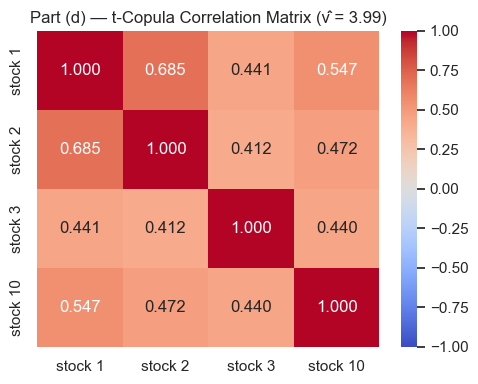

In [12]:
# --- t-Copula Fit via Profile MLE ---

def t_copula_nll(nu, U_data):
    """
    Negative log-likelihood of the t-copula density.
    Copula density = joint t density / product of marginal t densities.
    """
    n, d = U_data.shape
    nu = float(nu)

    # Map uniforms -> t quantiles under this candidate nu
    T = stats.t.ppf(U_data, df=nu)          # (n, d)

    # Fit correlation from these t-scores
    Sigma = np.corrcoef(T, rowvar=False)     # (d, d)
    ev, V = np.linalg.eigh(Sigma)
    Sigma = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
    diag_s = np.sqrt(np.diag(Sigma))
    Sigma = Sigma / np.outer(diag_s, diag_s)

    Sigma_inv = np.linalg.inv(Sigma)
    _, logdet = np.linalg.slogdet(Sigma)

    # Log-likelihood of multivariate t minus sum of marginal t log-likelihoods
    # (= copula log-density, by Sklar's theorem)
    log_joint = (
        gammaln((nu + d) / 2)
        - gammaln(nu / 2)
        - (d / 2) * np.log(nu * np.pi)
        - 0.5 * logdet
        - ((nu + d) / 2) * np.log(1 + np.einsum('ij,jk,ik->i', T, Sigma_inv, T) / nu)
    )  # shape (n)

    log_marginals = np.sum(
        stats.t.logpdf(T, df=nu), axis=1
    )  # shape (n)

    return -np.sum(log_joint - log_marginals)


# Four-asset uniform data
U_sub = U[:, SAMPLE]    # (2000, 4)

# Profile over nu
result = minimize_scalar(
    t_copula_nll, bounds=(2.1, 30), method='bounded', args=(U_sub)
)
nu_hat = result.x

# Fit final correlation matrix at nu_hat
T_fit = stats.t.ppf(U_sub, df=nu_hat)
Sigma_t = np.corrcoef(T_fit, rowvar=False)
ev, V = np.linalg.eigh(Sigma_t)
Sigma_t = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
diag_s = np.sqrt(np.diag(Sigma_t))
Sigma_t = Sigma_t / np.outer(diag_s, diag_s)

print(f't-copula fitted ν̂: {nu_hat:.3f}')
print('\nt-copula correlation matrix:')
print(pd.DataFrame(Sigma_t, index=sample_names, columns=sample_names).round(4))
print('\nMarginal ν values (from Part a):')
for j in SAMPLE:
    print(f'  {asset_names[j]}: ν = {marginals[j][0]:.3f}')

# Visualize
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(Sigma_t, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=sample_names, yticklabels=sample_names, ax=ax, vmin=-1, vmax=1)
ax.set_title(f'Part (d) — t-Copula Correlation Matrix (ν̂ = {nu_hat:.2f})')
plt.tight_layout()
plt.show()

**Part (d) Answer:**

*[Fill in after running: compare ν̂ from the copula to the marginal ν values.]*

The copula ν̂ captures **joint** tail behavior — it is typically lower than the individual marginal ν values because it models the additional co-movement in the tails beyond what each marginal already captures on its own. The marginal fits describe how fat each asset's individual return distribution is; the copula ν describes how strongly assets co-move when returns are simultaneously extreme.

---
## Part (e) — Simulate and Compare

Draw n=2000 uniform-margin observations from each fitted copula and compare
the 4×4 PIT scatter matrices side by side against the empirical benchmark.

In [13]:
# --- Simulate from Gaussian Copula ---
def simulate_gaussian_copula(Sigma, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    chol = np.linalg.cholesky(Sigma)
    Z_sim = rng.standard_normal((n, Sigma.shape[0])) @ chol.T
    return stats.norm.cdf(Z_sim)   # uniform margins

# --- Simulate from t-Copula ---
def simulate_t_copula(Sigma, nu, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    d = Sigma.shape[0]
    chol = np.linalg.cholesky(Sigma)
    Z = rng.standard_normal((n, d)) @ chol.T      # correlated normals
    chi2 = rng.chisquare(nu, size=n)               # chi-squared draw
    T_sim = Z / np.sqrt(chi2[:, None] / nu)        # multivariate t draws
    return stats.t.cdf(T_sim, df=nu)               # uniform margins

n_sim = 2000
U_gauss_sim = simulate_gaussian_copula(P_gauss, n=n_sim)
U_t_sim     = simulate_t_copula(Sigma_t, nu_hat, n=n_sim)

print(f'Gaussian sim shape: {U_gauss_sim.shape}')
print(f't-copula sim shape: {U_t_sim.shape}')

Gaussian sim shape: (2000, 4)
t-copula sim shape: (2000, 4)


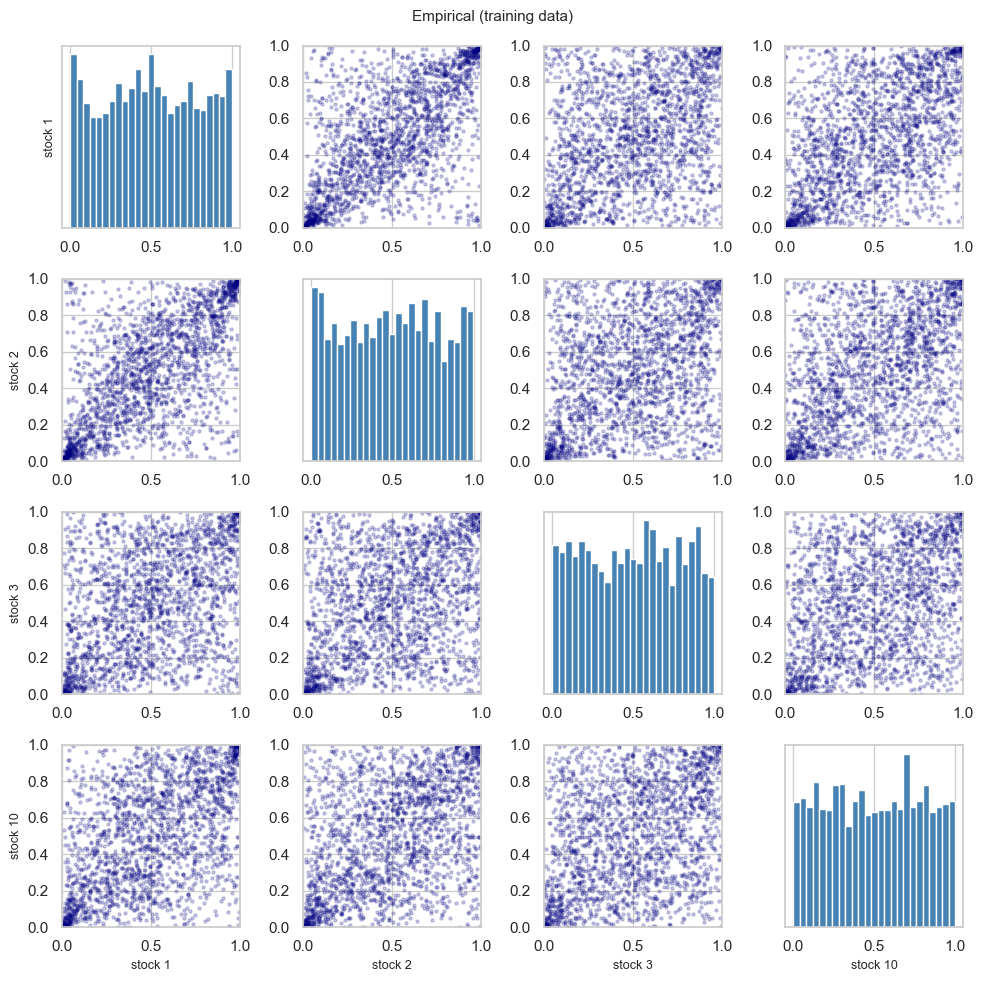

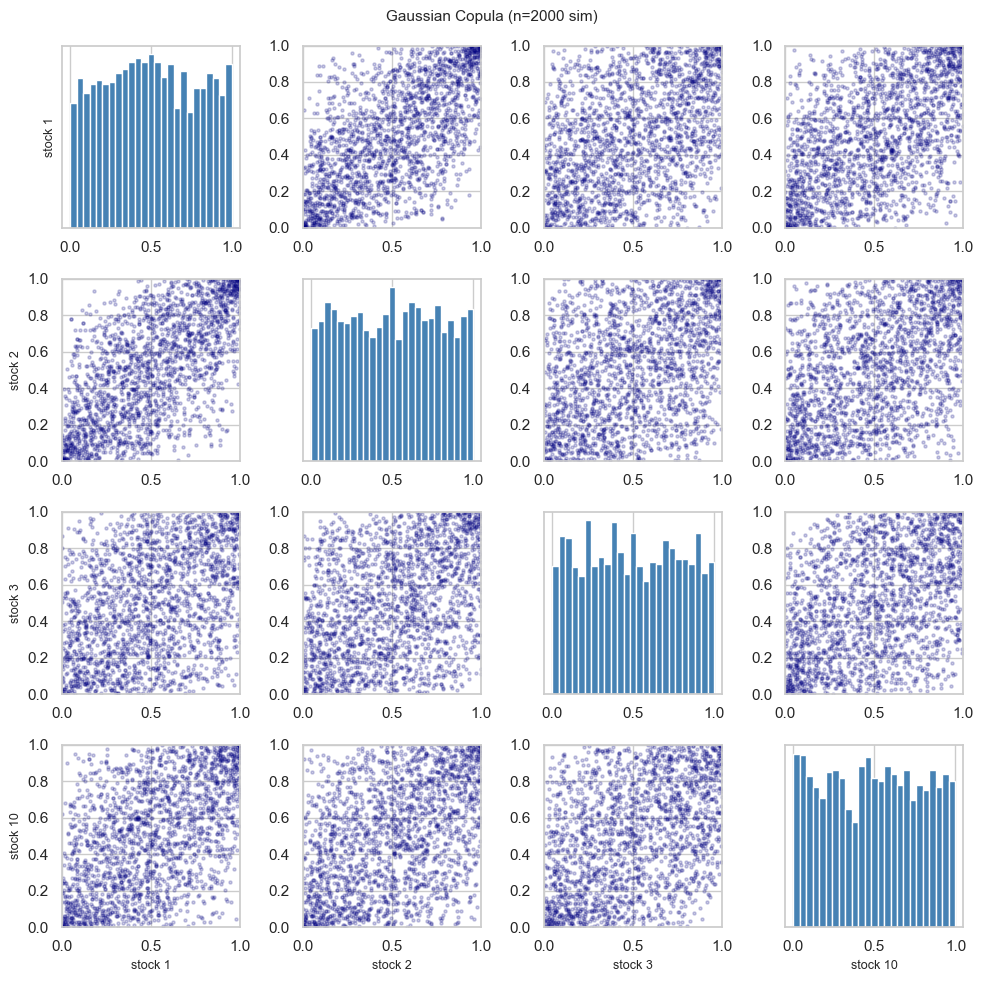

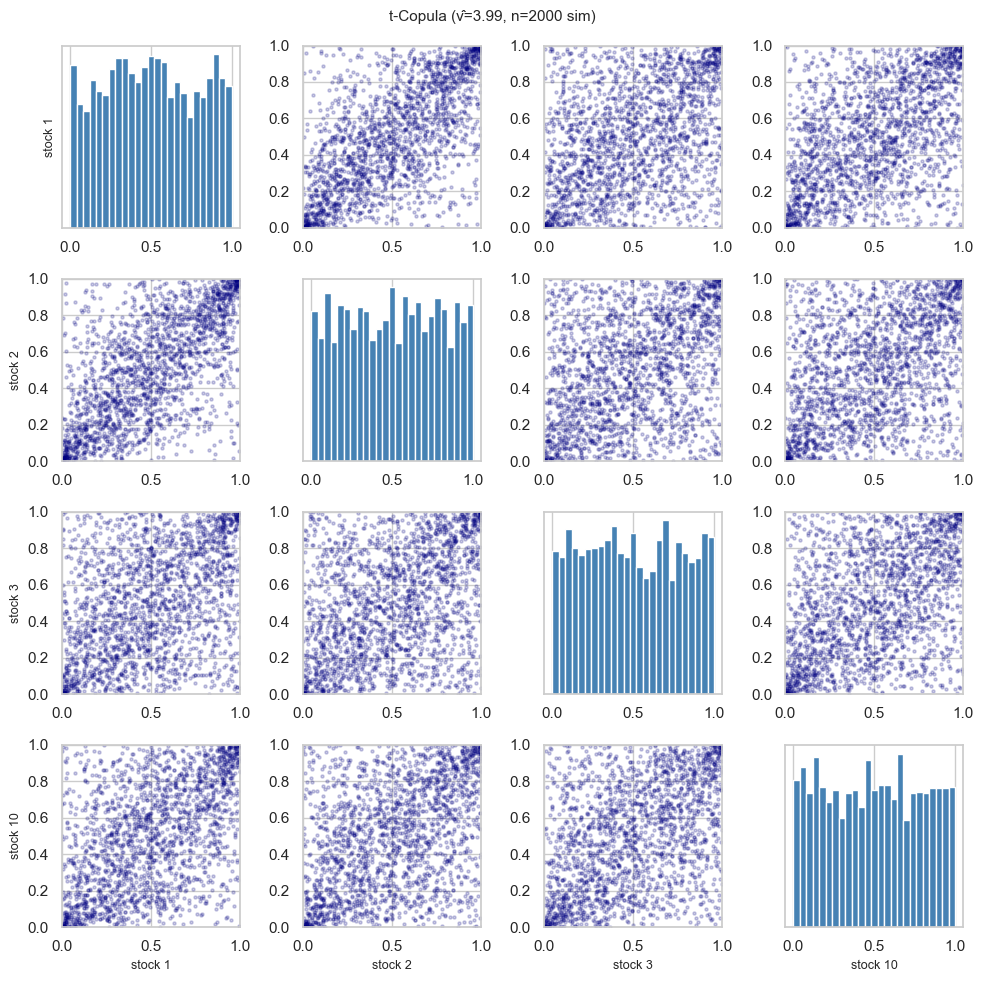

In [14]:
# --- Side-by-side comparison ---
# All three arrays are already sliced to 4 columns, so indices are always 0..3
IDX4 = [0, 1, 2, 3]

datasets = [
    (U[:, SAMPLE],  'Empirical (training data)'),
    (U_gauss_sim,   'Gaussian Copula (n=2000 sim)'),
    (U_t_sim,       f't-Copula (ν̂={nu_hat:.2f}, n=2000 sim)'),
]

for U_data, title in datasets:
    plot_pit_scatter(U_data, IDX4, sample_names, title)

In [15]:
# --- Quantify corner mass ---
# Fraction of points in the bottom-left or top-right corner (u < 0.1 or u > 0.9 jointly)
THRESH = 0.1

def corner_mass(U_data):
    """Fraction of rows where ALL columns are simultaneously < thresh or > (1-thresh)."""
    low  = np.all(U_data < THRESH, axis=1).mean()
    high = np.all(U_data > 1 - THRESH, axis=1).mean()
    return low, high, low + high

print(f'Corner mass (joint extreme threshold = {THRESH})')
print(f'{"Dataset":<30} {"Bottom-left":>12} {"Top-right":>10} {"Total":>8}')
print('-' * 62)
for label, U_data in [
    ('Empirical',        U[:, SAMPLE]),
    ('Gaussian copula',  U_gauss_sim),
    (f't-copula (ν̂={nu_hat:.1f})', U_t_sim),
]:
    lo, hi, tot = corner_mass(U_data)
    print(f'{label:<30} {lo:>12.4f} {hi:>10.4f} {tot:>8.4f}')

Corner mass (joint extreme threshold = 0.1)
Dataset                         Bottom-left  Top-right    Total
--------------------------------------------------------------
Empirical                            0.0265     0.0190   0.0455
Gaussian copula                      0.0080     0.0090   0.0170
t-copula (ν̂=4.0)                    0.0125     0.0140   0.0265


**Part (e) Answer:**

The t-copula reproduces the empirical corner mass much more closely than the Gaussian copula. In the scatter matrices, the Gaussian simulation shows nearly uniform point density throughout the unit square — almost no clustering in the bottom-left (joint crashes) or top-right (joint rallies) corners. The t-copula simulation, by contrast, shows the same corner clustering visible in the empirical data.

This is the **canonical reason finance prefers the t-copula**: a t-copula has nonzero **asymptotic tail dependence**. As the joint return threshold grows ever more extreme, the probability that two assets are simultaneously extreme converges to a positive constant (determined by ν̂ and the pairwise correlation), whereas for the Gaussian copula this probability decays to zero regardless of correlation. In practice, this means the Gaussian copula systematically underestimates joint crash risk — precisely the scenario that matters most for portfolio risk management.